
# ASV-Taxonomy Preprocessing for Input of Metapep Pipeline

This notebook processes two datasets:
- `humanASV.xlsx`: ASVs from 150 human gut samples (without abundances)
- `soilASV.tsv`: ASVs from soil samples from QUHPG project

The goal is to:
1. Combine and format taxonomy for NCBI strain-level lookup
2. Assign NCBI TaxIDs at strain level
3. Generate condition tables (with abundances) compatible with metapep Pipeline


### Imports

In [8]:
import pandas as pd
import subprocess
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from Bio import Entrez
import time
from collections import defaultdict
import sys
import xml.etree.ElementTree as ET
from urllib.error import HTTPError

Entrez.email = "f.kramer@student.uni-tuebingen.de"

### Load Data

In [9]:
# Load human ASV taxonomy (no abundance, no sequences)
humanData = pd.read_excel("humanASV.xlsx")
#print(humanData.head())

# Load soil ASV table (contains abundances)
soilData = pd.read_csv("soilASV.tsv", sep='\t')
#print(soilData.head())

### Filter the Data

In [10]:
# Helper functions for filtering and taxonomy creating (for taxonkit)
def filter_valid_entries(df):
    return df[(df["confidence"] > 0.95) & (df["Species"].notna()) & (df["Species"].str.contains(r"[a-zA-Z]+", na=False))]


def build_tax_string(entry):
    ranks = ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']
    return ";".join([str(entry[r]) for r in ranks if pd.notna(entry[r])])


# Filter for Entries that are defined on Species Level with regular expression char^n with n >= 1 (Alternative: r'.+')
humanFiltered = filter_valid_entries(humanData).copy()
soilFiltered = filter_valid_entries(soilData).copy()

# Add taxonomy column for taxonkit
humanFiltered["taxonomy"] = humanFiltered.apply(build_tax_string, axis=1)
soilFiltered["taxonomy"] = soilFiltered.apply(build_tax_string, axis=1)

#print(humanFiltered.head())
#print(soilFiltered.head())



# Collapse abundance per taxonomy: Reset Index and Group Soil Data Baed on Taxonomy (Put all replicates and timestamps together)
humanDataGrouped = humanFiltered.groupby(["taxonomy"]).size().reset_index(name="abundance")
numericColumns = soilFiltered.select_dtypes(include="number").columns
sample_cols = [col for col in numericColumns if col in soilFiltered.columns[12:]]
soilFiltered["abundance"] = soilFiltered[sample_cols].sum(axis=1)
soilDataGrouped = soilFiltered.groupby(["taxonomy"])["abundance"].sum().reset_index()

print(humanDataGrouped.head())
print(soilDataGrouped.head())



                                            taxonomy  abundance
0  Archaea;Euryarchaeota;Methanobacteria;Methanob...          1
1  Archaea;Euryarchaeota;Methanobacteria;Methanob...          3
2  Archaea;Thermoplasmatota;Thermoplasmata;Methan...          1
3  Bacteria;Actinobacteriota;Actinobacteria;Actin...          1
4  Bacteria;Actinobacteriota;Actinobacteria;Actin...          1
                                            taxonomy  abundance
0  Bacteria;Actinobacteriota;Actinobacteria;Coryn...   0.000568
1  Bacteria;Actinobacteriota;Actinobacteria;Coryn...   0.004368
2  Bacteria;Actinobacteriota;Actinobacteria;Coryn...   0.006465
3  Bacteria;Actinobacteriota;Actinobacteria;Coryn...   0.000984
4  Bacteria;Actinobacteriota;Actinobacteria;Coryn...   0.001761


### Vizualize Relationship between the two datasets

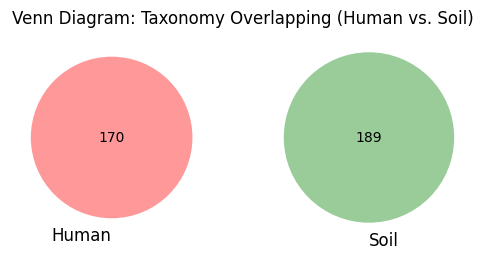

In [11]:
# Build sets out of taxonomy lists and vizualize them in a venndiagram
setHuman = set(humanDataGrouped['taxonomy'])
setSoil = set(soilDataGrouped['taxonomy'])

plt.figure(figsize=(6,6))
venn2([setHuman, setSoil], set_labels=('Human', 'Soil'))
plt.title("Venn Diagram: Taxonomy Overlapping (Human vs. Soil)")
plt.show()


### Convert taxonomy to NCBI TaxID (Strain level)

This part requires mapping each taxonomy string to a `TaxID` (Used [`taxonkit`](https://bioinf.shenwei.me/taxonkit/))


In [15]:
# Helper functions to prepare taxonkit (parse TaxID list), connect to NCBI Database and map Taxonomy on TaxID
def run_taxonkit_name2taxid(names):
    with open("temp_taxonomy_input.txt", "w") as f:
        for name in names:
            f.write(name + "\n")
    cmd = ["taxonkit", "name2taxid"]
    with open("temp_taxonomy_input.txt", "r") as infile, open("temp_taxid_output.txt", "w") as outfile:
        subprocess.run(cmd, stdin=infile, stdout=outfile, check=True)
    df = pd.read_csv("temp_taxid_output.txt", sep="\t", header=None, names=["name", "taxon_id"])
    return df.dropna()

def run_taxonkit_list(taxid):
    cmd = ["taxonkit", "list", "-n", "-r"]
    proc = subprocess.run(cmd, input=str(taxid), text=True, capture_output=True, check=False)
    if proc.returncode != 0:
        print("Taxonkit List Error")
        return None
    return proc.stdout

def parse_taxonkit_list_output(output):
    lines = output.strip().split("\n")
    parsed = []
    for line in lines:
        indent = len(line) - len(line.lstrip(" "))
        line = line.strip()
        if "[" in line and "]" in line:
            try:
                taxonIDString, rest = line.split("[", 1)
                rank = rest.split("]", 1)[0].strip()
                taxonID = taxonIDString.strip().split(" ")[0]
                parsed.append({"taxon_id": taxonID, "rank": rank, "level": indent})
            except Exception as e:
                print(f"[WARN] Could not parse line: {line} ({e})")
    return parsed

def get_rank_of_taxid(taxid):
    output = run_taxonkit_list(taxid)
    if not output:
        return None
    parsed = parse_taxonkit_list_output(output)
    if parsed:
        return parsed[0]["rank"]
    return None

def extract_species_name(tax_string):
    parts = str(tax_string).split(";")
    if len(parts) < 2:
        return None
    genus = parts[-2].strip()
    species = parts[-1].strip()
    return f"{genus} {species}"

def get_assembly_length(assemblyId):
    success = False
    for attempt in range(3):
        try:
            with Entrez.efetch(db="assembly", rettype="docsum", id=assemblyId) as entrez_handle:
                assembly_stats = Entrez.read(entrez_handle, validate=False)
            time.sleep(1)  # avoid getting blocked by ncbi
            success = True
            break
        except HTTPError as err:
            if 500 <= err.code <= 599:
                print("Received error from server %s" % err)
                print("Attempt %i of 3" % attempt)
                time.sleep(10)
            else:
                raise
    if not success:
        sys.exit("Entrez efetch download failed!")

    root = ET.fromstring("<root>" + str(assembly_stats["DocumentSummarySet"]["DocumentSummary"][0]["Meta"]) + "</root>")
    return int(root.find("./Stats/Stat[@category='total_length'][@sequence_tag='all']").text)

def entrez_has_valid_genome(taxid):
    try:
        handle = Entrez.esearch(db="assembly", term=f"txid{taxid}[Organism:exp]", retmax=5)
        search_result = Entrez.read(handle)
        handle.close()

        # Get longest assembly ID from list
        assembly_ids = search_result.get("IdList", [])
        print(f"Found {len(assembly_ids)} Assemblies.")
        lengths = [get_assembly_length(id) for id in assembly_ids]
        if lengths:
            max_index = lengths.index(max(lengths))
            longestAssembly = assembly_ids[max_index]
        else:
            longestAssembly = None

        if not search_result["IdList"]:
            print(f"No assemblies found for taxid {taxid}")
            return False

        for assembly_id in search_result["IdList"]:
            # Assembly -> Nucleotide
            link_handle = Entrez.elink(dbfrom="assembly", db="nuccore", LinkName="assembly_nuccore_refseq", id=assembly_id)
            nuccore_result = Entrez.read(link_handle)
            link_handle.close()

            if "LinkSetDb" in nuccore_result[0] and nuccore_result[0]["LinkSetDb"]:
                nucleotide_links = nuccore_result[0]["LinkSetDb"][0]["Link"]
                if not nucleotide_links:
                    continue
                nucleotide_ids = [link["Id"] for link in nucleotide_links]

                # Nucleotide -> Protein
                prot_link_handle = Entrez.elink(dbfrom="nuccore", db="protein", LinkName="nuccore_protein", id=nucleotide_ids)
                prot_result = Entrez.read(prot_link_handle)
                prot_link_handle.close()

                if prot_result and "LinkSetDb" in prot_result[0] and prot_result[0]["LinkSetDb"]:
                    protein_links = prot_result[0]["LinkSetDb"][0]["Link"]
                    if protein_links:
                        print(f"TaxID {taxid}: Valid assembly with id {assembly_id} with nucleotide and protein sequences found.")

                        # Check if longest is valid
                        if assembly_id != longestAssembly:
                            link_handle = Entrez.elink(dbfrom="assembly", db="nuccore", LinkName="assembly_nuccore_refseq", id=longestAssembly)
                            nuccore_result = Entrez.read(link_handle)
                            link_handle.close()
                            if "LinkSetDb" in nuccore_result[0] and nuccore_result[0]["LinkSetDb"]:
                                nucleotide_links = nuccore_result[0]["LinkSetDb"][0]["Link"]
                                if not nucleotide_links:
                                    return print("Longest Assembly has no valid entry.")
                                nucleotide_ids = [link["Id"] for link in nucleotide_links]
                                prot_link_handle = Entrez.elink(dbfrom="nuccore", db="protein", LinkName="nuccore_protein", id=nucleotide_ids)
                                prot_result = Entrez.read(prot_link_handle)
                                prot_link_handle.close()
                                if prot_result and "LinkSetDb" in prot_result[0] and prot_result[0]["LinkSetDb"]:
                                    protein_links = prot_result[0]["LinkSetDb"][0]["Link"]
                                    if protein_links:
                                        print("Longest Assembly has also valid entry.")
                        else:
                            print("Longest assembly is the found one.")
                        # Still found one assembly
                        return True

        print(f"No valid genome with nucleotide and protein link found for taxid {taxid}")
        return False

    except Exception as e:
        print(f"[ERROR] Entrez genome/protein check failed for taxid {taxid}: {e}")
        return False


# Main Functions that combines all steps defined above
def map_taxonomy_to_taxid(df, tax_column="taxonomy"):
    df = df.copy()
    df["species_name"] = df[tax_column].apply(extract_species_name)
    uniqueSpecies = df["species_name"].dropna().unique()

    nameTaxIDMap = run_taxonkit_name2taxid(uniqueSpecies)
    taxIDMap = dict(zip(nameTaxIDMap["name"], nameTaxIDMap["taxon_id"]))

    finalRows = []

    for _, row in df.iterrows():
        name = row["species_name"]
        print(f"Process Species {name}")
        if name not in taxIDMap:
            print(f"[WARN] No TaxID found for: {name}")
            print()
            continue
        taxid = int(taxIDMap[name])

        output = run_taxonkit_list(taxid)
        if not output:
            print(f"[ERROR] taxonkit list failed for taxid {taxid}")
            print()
            continue

        parsed = parse_taxonkit_list_output(output)
        if not parsed:
            print(f"[ERROR] Could not parse taxonkit output for {taxid}")
            print()
            continue

        rank = get_rank_of_taxid(taxid)
        print(f"TaxID: {taxid}  Rank: {rank}")
        if rank == "strain":
            finalRows.append({"taxon_id": taxid, "abundance": row.get("abundance", 0)})
            print(f"TaxID {taxid} is already a strain")
            print()
        else:
            strainEntries = [p for p in parsed if p["rank"] == "strain"]
            if strainEntries:
                print(f"{len(strainEntries)} Strain entries found. Start processing...")
                found = False
                for strain in strainEntries:
                    strain_taxid = strain["taxon_id"]
                    print(f"Check genome for strain taxid {strain_taxid}...")
                    if entrez_has_valid_genome(strain_taxid):
                        finalRows.append({"taxon_id": strain_taxid, "abundance": row.get("abundance", 0)})
                        print(f"Mapped to strain with genome: {strain_taxid}")
                        print()
                        found = True
                        break
                    else:
                        print(f"Strain {strain_taxid} has no genome.")
                if not found:
                    print("No strain with genome found")
                    print()
            else:
                print("No strain found")
                print()

    resultData = pd.DataFrame(finalRows)
    #print(resultData)
    #resultData["taxon_id"] = resultData["taxon_id"].astype(int)
    return resultData



# Execute Name to TaxID Mapping
print("Processing Soil Microbiome: \n \n")
soilDataFinal = map_taxonomy_to_taxid(soilDataGrouped)
print("Processing Human Microbiome: \n \n")
humanDataFinal = map_taxonomy_to_taxid(humanDataGrouped)


print(humanDataFinal.head())
print(soilDataFinal.head())

Processing Soil Microbiome: 
 

Process Species Mycobacterium confluentis
TaxID: 28047  Rank: species
No strain found

Process Species Mycobacterium holsaticum
TaxID: 152142  Rank: species
1 Strain entries found. Start processing...
Check genome for strain taxid 1226752...
Found 3 Assemblies.
TaxID 1226752: Valid assembly with id 15445141 with nucleotide and protein sequences found.
Longest Assembly has also valid entry.
Mapped to strain with genome: 1226752

Process Species Mycobacterium madagascariense
TaxID: 212765  Rank: species
No strain found

Process Species Nocardia jejuensis
TaxID: 328049  Rank: species
1 Strain entries found. Start processing...
Check genome for strain taxid 1210088...
Found 2 Assemblies.
TaxID 1210088: Valid assembly with id 21724821 with nucleotide and protein sequences found.
Longest assembly is the found one.
Mapped to strain with genome: 1210088

Process Species Rhodococcus jostii
TaxID: 132919  Rank: species
2 Strain entries found. Start processing...
C

KeyboardInterrupt: 

### Export result into PipelineInput Folder 

In [ ]:
'''
dropIfNoStrain = True  # Drops entry if no strain is found (else: Fallback on Species Level)
#TAXONKIT_CWD = "/Users/FlorianKramer/Desktop/MetapepPipeline/PipelineInput/DataFactory"

# Helper functions to prepare taxonkit (parse TaxID list), connect to NCBI Database and map Taxonomy on TaxID
def run_taxonkit_name2taxid(names):
    with open("temp_taxonomy_input.txt", "w") as f:
        for name in names:
            f.write(name + "\n")
    cmd = ["taxonkit", "name2taxid"]
    with open("temp_taxonomy_input.txt", "r") as infile, open("temp_taxid_output.txt", "w") as outfile:
        subprocess.run(cmd, stdin=infile, stdout=outfile, check=True)
    df = pd.read_csv("temp_taxid_output.txt", sep="\t", header=None, names=["name", "taxon_id"])
    return df.dropna()

def run_taxonkit_list(taxid):
    cmd = ["taxonkit", "list", "-n", "-r"]
    proc = subprocess.run(cmd, input=str(taxid), text=True, capture_output=True, check=False)
    if proc.returncode != 0:
        print("Taxonkit List Error")
        return None
    return proc.stdout

def parse_taxonkit_list_output(output):
    lines = output.strip().split("\n")
    parsed = []
    for line in lines:
        indent = len(line) - len(line.lstrip(" "))
        line = line.strip()
        if "[" in line and "]" in line:
            try:
                taxonIDString, rest = line.split("[", 1)
                rank = rest.split("]", 1)[0].strip()
                taxonID = taxonIDString.strip().split(" ")[0]
                parsed.append({"taxon_id": taxonID, "rank": rank, "level": indent})
            except Exception as e:
                print(f"[WARN] Could not parse line: {line} ({e})")
    return parsed

def get_rank_of_taxid(taxid):
    output = run_taxonkit_list(taxid)
    if not output:
        return None
    parsed = parse_taxonkit_list_output(output)
    if parsed:
        return parsed[0]["rank"]
    return None

def extract_species_name(tax_string):
    parts = str(tax_string).split(";")
    if len(parts) < 2:
        return None
    genus = parts[-2].strip()
    species = parts[-1].strip()
    return f"{genus} {species}"

def entrez_has_genome(taxid):
    try:
        # Get assemblies for this taxid
        handle = Entrez.esearch(db="assembly", term=f"txid{taxid}[Organism:exp]", retmax=5)
        search_result = Entrez.read(handle)
        handle.close()

        if not search_result["IdList"]:
            print(f"No assemblies found for taxid {taxid}")
            return False

        for assembly_id in search_result["IdList"]:
            # Use elink to find nucleotide sequences linked to this assembly
            link_handle = Entrez.elink(dbfrom="assembly", db="nucleotide", id=assembly_id)
            link_result = Entrez.read(link_handle)
            link_handle.close()

            if link_result and "LinkSetDb" in link_result[0] and link_result[0]["LinkSetDb"]:
                for db in link_result[0]["LinkSetDb"]:
                    if db["Link"]:
                        print(f"TaxID {taxid}: Assembly {assembly_id} has linked nucleotide sequences.")
                        return True
                print(f"TaxID {taxid}: Assembly {assembly_id} has no nucleotide links.")
            else:
                print(f"TaxID {taxid}: Assembly {assembly_id} has no LinkSetDb.")
            time.sleep(0.4)

        print(f"No valid genome with nucleotide link found for taxid {taxid}")
        return False

    except Exception as e:
        print(f"[ERROR] Entrez genome check failed for taxid {taxid}: {e}")
        return False




# Main Functions that combines all steps defined above
def map_taxonomy_to_taxid(df, tax_column="taxonomy"):
    df = df.copy()
    df["species_name"] = df[tax_column].apply(extract_species_name)
    uniqueSpecies = df["species_name"].dropna().unique()

    nameTaxIDMap = run_taxonkit_name2taxid(uniqueSpecies)
    taxIDMap = dict(zip(nameTaxIDMap["name"], nameTaxIDMap["taxon_id"]))

    finalRows = []

    for _, row in df.iterrows():
        name = row["species_name"]
        print(f"Process Species {name}")
        if name not in taxIDMap:
            print(f"[WARN] No TaxID found for: {name}")
            print()
            continue
        taxid = int(taxIDMap[name])

        output = run_taxonkit_list(taxid)
        if not output:
            print(f"[ERROR] taxonkit list failed for taxid {taxid}")
            print()
            continue

        parsed = parse_taxonkit_list_output(output)
        if not parsed:
            print(f"[ERROR] Could not parse taxonkit output for {taxid}")
            print()
            continue

        rank = get_rank_of_taxid(taxid)
        print(f"TaxID: {taxid}  Rank: {rank}")
        if rank == "strain":
            finalRows.append({"taxon_id": taxid, "abundance": row.get("abundance", 0)})
            print("Already a strain")
        else:
            strainEntries = [p for p in parsed if p["rank"] == "strain"]
            if strainEntries:
                found = False
                for strain in strainEntries:
                    strain_taxid = strain["taxon_id"]
                    print(f"Check genome for strain taxid {strain_taxid}...")
                    if entrez_has_genome(strain_taxid):
                        finalRows.append({"taxon_id": strain_taxid, "abundance": row.get("abundance", 0)})
                        print(f"Mapped to strain with genome: {strain_taxid}")#
                        print()
                        found = True
                        break
                    else:
                        print(f"Strain {strain_taxid} has no genome.")
                if not found:
                    print("No strain with genome found")
                    if not dropIfNoStrain:
                        finalRows.append({"taxon_id": taxid, "abundance": row.get("abundance", 0)})
                        print("No genome strain found, kept species")
            else:
                print("No strain found")
                print()
                if not dropIfNoStrain:
                    finalRows.append({"taxon_id": taxid, "abundance": row.get("abundance", 0)})
                    print("No strain found, kept species")
                    print()

    resultData = pd.DataFrame(finalRows)
    #print(resultData)
    #resultData["taxon_id"] = resultData["taxon_id"].astype(int)
    return resultData



# Execute Name to TaxID Mapping
soilDataFinal = map_taxonomy_to_taxid(soilDataGrouped)
humanDataFinal = map_taxonomy_to_taxid(humanDataGrouped)

print(humanDataFinal.head())
print(soilDataFinal.head())
'''

In [ ]:

humanDataFinal.to_csv("../humanMicrobiome.tsv", sep="\t", index=False)
soilDataFinal.to_csv("../soilMicrobiome.tsv", sep="\t", index=False)
